### Tasks

* 1. Given two arrays: one with actual delivery times and one with predicted delivery times for 10 Zomato orders, calculate the Mean Squared Error (MSE) and Root Mean Squared Error (RMSE) using Python.

In [1]:
import numpy as np
import pandas as pd

In [2]:
Actual_devlivery_time = np.array([10, 15, 30, 18, 12, 22, 31, 28, 24, 11])
Predicted_devlivery_time = np.array([15, 18, 25, 29, 16, 27, 30, 32, 29, 9])

In [3]:
from sklearn.metrics import mean_squared_error

In [4]:
mse = mean_squared_error(Actual_devlivery_time, Predicted_devlivery_time)
rmse = np.sqrt(mse)

In [5]:
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 26.7
RMSE: 5.167204273105526


* 2. For a Flipkart product price prediction task, you have arrays of actual prices and predicted prices. Write a function to compute the Mean Absolute Error (MAE) and R² score, and print both values.<br><br><em><strong>Hint:</strong> Use sklearn.metrics.mean_absolute_error and sklearn.metrics.r2_score.</em>

In [6]:
Actual_price = np.array([1000, 1500, 2000, 2500, 3000])
Pred_price = np.array([1100, 1400, 1950, 2600, 2900])

from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(Actual_price, Pred_price)
r2 = r2_score(Actual_price, Pred_price)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 90.0
R2 Score: 0.983


* 3. Create a residual plot for a dataset of actual vs predicted movie ratings (scale 1-5) for 20 movies, using matplotlib. Label the axes and briefly describe what the plot tells you about your model's errors.

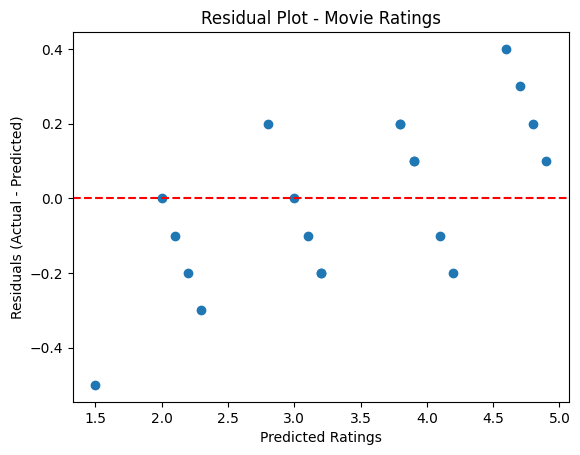

In [7]:
actual = np.array([4,3,5,2,4,3,5,1,2,4,3,5,4,2,3,5,4,3,2,4])
predicted = np.array([3.8,3.2,4.6,2.1,3.9,2.8,4.7,1.5,2.3,4.1,
                      3.0,4.8,4.2,2.2,3.1,4.9,3.9,3.2,2.0,3.8])

residuals = actual - predicted

import matplotlib.pyplot as plt

plt.scatter(predicted, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Ratings")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot - Movie Ratings")
plt.show()

* 4. You have two models predicting the delivery time for Swiggy orders. Model A has an RMSE of 8 minutes and R² of 0.65, Model B has an RMSE of 6 minutes and R² of 0.55. Which model would you choose and why? Explain your reasoning based on the evaluation metrics.

### Explanation:
I would choose Model B because it has lower RMSE, meaning its predictions are closer to actual delivery times, which is more important in real-time delivery systems.

* 5. Compare two regression models for predicting Spotify song popularity: calculate MSE, RMSE, MAE, and R² for both models using sklearn, then identify which model is likely overfitting based on the results.<br><br><em><strong>Hint:</strong> Overfitting often shows very low error on training data but much higher error on test data.</em>

In [8]:
df = pd.read_csv(r"C:\Users\patel prit\OneDrive\Desktop\Assessment\ML\Assignment\Supervised\Session - 2\Spotify.csv", encoding="latin1")
df.head()

,Column1,Track.Name,Artist.Name,Genre,Beats.Per.Minute,Energy,Danceability,Loudness..dB..,Liveness,Valence.,Length.,Acousticness..,Speechiness.,Popularity
0,1,SeÃ±orit,Shawn Mendes,canadian pop,117,55,76,-6,8,75,191,4,3,79
1,2,China,Anuel AA,reggaeton flow,105,81,79,-4,8,61,302,8,9,92
2,3,boyfriend (with Social House),Ariana Grande,dance pop,190,80,40,-4,16,70,186,12,46,85
3,4,Beautiful People (feat. Khalid),Ed Sheeran,pop,93,65,64,-8,8,55,198,12,19,86
4,5,Goodbyes (Feat. Young Thug),Post Malone,dfw rap,150,65,58,-4,11,18,175,45,7,94


In [9]:
X = df.select_dtypes(include=['number']).drop(columns=['Column1', 'Popularity'], errors='ignore')
y = df['Popularity']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.tree import DecisionTreeRegressor

model1 = DecisionTreeRegressor()
model1.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [12]:
from sklearn.linear_model import LinearRegression

model2 = LinearRegression()
model2.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
pred_train1 = model1.predict(X_train)
pred_test1 = model1.predict(X_test)

In [14]:
pred_train2 = model2.predict(X_train)
pred_test2 = model2.predict(X_test)

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [16]:
print("Model 1: Decision Tree Metrics\n")
print("Train MSE:", mean_squared_error(y_train, pred_train1))
print("Test MSE:", mean_squared_error(y_test, pred_test1))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, pred_train1)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, pred_test1)))
print("Train MAE:", mean_absolute_error(y_train, pred_train1))
print("Test MAE:", mean_absolute_error(y_test, pred_test1))
print("Train R²:", r2_score(y_train, pred_train1))
print("Test R²:", r2_score(y_test, pred_test1))

Model 1: Decision Tree Metrics

Train MSE: 0.0
Test MSE: 84.1
Train RMSE: 0.0
Test RMSE: 9.1706052144883
Train MAE: 0.0
Test MAE: 5.7
Train R²: 1.0
Test R²: -1.1625096425816408


In [18]:
print("Model 2: Linear Regression Metrics\n")
print("Train MSE:", mean_squared_error(y_train, pred_train2))
print("Test MSE:", mean_squared_error(y_test, pred_test2))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, pred_train2)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, pred_test2)))
print("Train MAE:", mean_absolute_error(y_train, pred_train2))
print("Test MAE:", mean_absolute_error(y_test, pred_test2))
print("Train R²:", r2_score(y_train, pred_train2))
print("Test R²:", r2_score(y_test, pred_test2))

Model 2: Linear Regression Metrics

Train MSE: 9.24467698626238
Test MSE: 53.82739404913433
Train RMSE: 3.0405060411488054
Test RMSE: 7.336715480999269
Train MAE: 2.404254638595928
Test MAE: 4.91139740257734
Train R²: 0.2821062328664431
Test R²: -0.3840934443079027
